# REV1-02 — Driver Classification (X/Y/Z)

Tujuan:
mengubah tabel event-level dari Notebook 1 menjadi klasifikasi pola driver.

Pertanyaan Prof yang dijawab:
- Apakah semua flash drought Indonesia mempunyai mekanisme yang sama?
- Apa yang membedakan satu kejadian dengan kejadian lain?

Output:
- P-dominated
- Demand-dominated
- Compound
- Mixed/unclear

Catatan:
ini adalah klasifikasi diagnostik, bukan klaim penyebab kausal.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path(r"D:\ERA5_LAND")

INPUT_FILE = (
    BASE / "output_fd_REV1_01_event_level_drivers"
    / "event_level_driver_table_RAW.parquet"
)

OUTPUT_DIR = BASE / "output_fd_REV1_02_driver_classification"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

events = pd.read_parquet(INPUT_FILE)

print("Rows:", f"{len(events):,}")
display(events.head())

Rows: 559,676


,event_id,time_index,year,pentad,latitude,longitude,onset_time_pentads,onset_speed_pp_per_pentad,duration_pentads,severity_p40_pp_pentad,...,precip_rapid,precip_delta_rapid_minus_pre,t2m_pre3,t2m_lag0,t2m_rapid,t2m_delta_rapid_minus_pre,vpd_pre3,vpd_lag0,vpd_rapid,vpd_delta_rapid_minus_pre
0,0,73,1996,1,-8.2,131.000000,2.0,11.246787,5.0,82.107971,...,20.255415,-15.841032,27.292856,27.117939,27.364389,0.071533,0.672773,0.652977,0.690988,0.018216
1,1,73,1996,1,-7.5,110.000000,1.0,32.133675,4.0,72.827766,...,90.915085,54.501869,21.180351,20.881618,21.168514,-0.011837,0.265141,0.205363,0.256161,-0.008980
2,2,73,1996,1,-7.2,108.599998,1.0,70.694092,4.0,101.748070,...,89.120743,24.298882,22.748146,22.123821,22.464638,-0.283508,0.282218,0.219914,0.268246,-0.013972
3,3,73,1996,1,-7.2,108.699997,1.0,54.627251,4.0,72.827766,...,77.327621,22.349911,22.088411,21.298641,21.704994,-0.383417,0.288346,0.201589,0.256662,-0.031685
4,4,73,1996,1,-7.0,111.300003,1.0,64.267349,4.0,95.321335,...,49.788418,-8.286972,25.467026,24.239914,24.920616,-0.546410,0.456690,0.254333,0.376225,-0.080465


## 1. Standardisasi perubahan dari antecedent ke rapid development

Kita gunakan perubahan:

rapid development - antecedent

karena pertanyaan kita adalah:
"apa yang berubah sebelum flash drought berkembang?"

In [2]:
required = [
    "precip_delta_rapid_minus_pre",
    "vpd_delta_rapid_minus_pre",
    "t2m_delta_rapid_minus_pre"
]

for c in required:
    if c not in events.columns:
        raise KeyError(f"Kolom tidak ditemukan: {c}")

def zscore(x):
    return (x - x.mean()) / x.std()

events["precip_z"] = zscore(
    events["precip_delta_rapid_minus_pre"]
)

events["vpd_z"] = zscore(
    events["vpd_delta_rapid_minus_pre"]
)

events["t2m_z"] = zscore(
    events["t2m_delta_rapid_minus_pre"]
)

display(
    events[
        ["precip_z","vpd_z","t2m_z"]
    ].describe()
)

,precip_z,vpd_z,t2m_z
count,5.596760e+05,5.596760e+05,5.596760e+05
mean,-1.657628e-08,5.583588e-08,1.744871e-08
std,1.000034e+00,1.000001e+00,9.999911e-01
min,-1.415702e+01,-1.151001e+01,-6.378358e+00
25%,-4.920751e-01,-6.610602e-01,-6.675810e-01
50%,3.065750e-02,-9.868643e-02,-1.968564e-02
75%,5.138687e-01,5.571451e-01,6.401627e-01
max,1.282726e+01,7.280106e+00,4.638884e+00


## 2. Klasifikasi awal

Interpretasi:

P-dominated:
- precipitation turun kuat
- VPD tidak meningkat kuat

Demand-dominated:
- VPD meningkat kuat
- precipitation tidak turun kuat

Compound:
- precipitation turun
- VPD meningkat

Threshold 0.5 hanya tahap eksplorasi dan harus diuji sensitivitas.

In [3]:
THRESH = 0.5

events["driver_type"] = "Mixed_unclear"

p_dry = events["precip_z"] < -THRESH
vpd_high = events["vpd_z"] > THRESH

events.loc[
    p_dry & (~vpd_high),
    "driver_type"
] = "P_dominated"

events.loc[
    (~p_dry) & vpd_high,
    "driver_type"
] = "Demand_dominated"

events.loc[
    p_dry & vpd_high,
    "driver_type"
] = "Compound"

print(
    events["driver_type"]
    .value_counts()
)

print("\nPercentage:")
print(
    (events["driver_type"]
     .value_counts(normalize=True)*100)
     .round(2)
)

driver_type
Mixed_unclear       333848
Demand_dominated     87509
P_dominated          76494
Compound             61825
Name: count, dtype: int64

Percentage:
driver_type
Mixed_unclear       59.65
Demand_dominated    15.64
P_dominated         13.67
Compound            11.05
Name: proportion, dtype: float64


In [4]:
summary = (
    events
    .groupby("driver_type")
    [
        [
            "precip_z",
            "vpd_z",
            "t2m_z",
            "onset_time_pentads",
            "severity_p40_pp_pentad"
        ]
    ]
    .median()
)

display(summary)

,precip_z,vpd_z,t2m_z,onset_time_pentads,severity_p40_pp_pentad
driver_type,,,,,
Compound,-0.978786,1.169106,0.979236,1.0,145.655533
Demand_dominated,-0.013378,1.017265,0.781544,2.0,151.362473
Mixed_unclear,0.339619,-0.458055,-0.305872,2.0,129.588684
P_dominated,-0.938568,-0.130311,-0.128067,1.0,129.588684


## 3. Variasi antar tahun

Digunakan untuk melihat apakah tahun ekstrem mempunyai komposisi driver berbeda.

driver_type,Compound,Demand_dominated,Mixed_unclear,P_dominated
year,,,,
1996,10.8,18.3,57.2,13.7
1997,8.0,17.1,64.9,10.1
1998,3.6,8.7,76.5,11.2
1999,7.0,10.3,71.0,11.6
2000,6.4,15.1,65.5,13.0
2001,9.8,21.5,57.0,11.8
2002,16.4,17.7,54.4,11.5
2003,19.3,19.2,47.1,14.3
2004,12.4,23.0,55.7,8.8


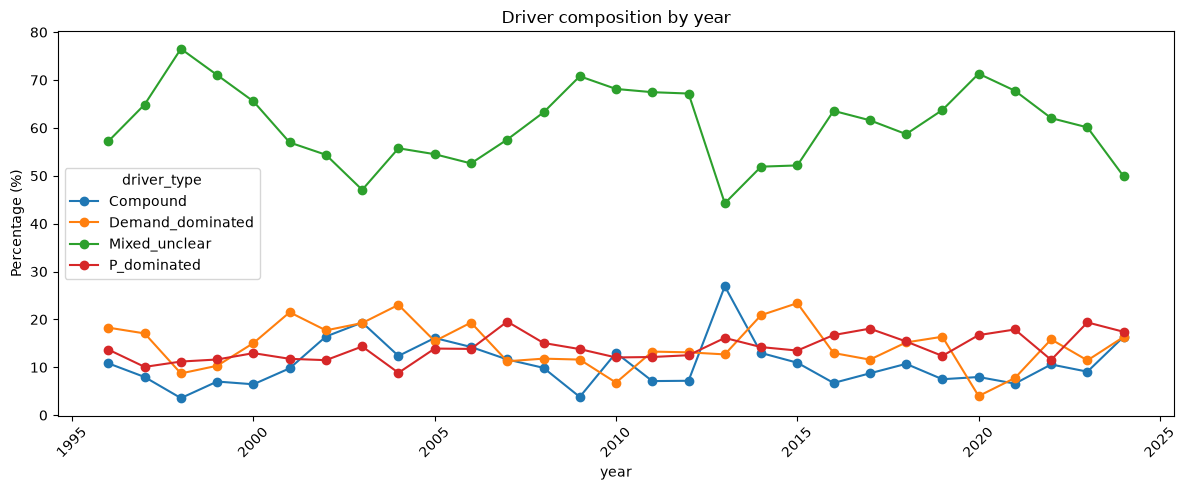

In [5]:
year_comp = pd.crosstab(
    events["year"],
    events["driver_type"],
    normalize="index"
)*100

display(year_comp.round(1))

year_comp.plot(
    figsize=(12,5),
    marker="o"
)

plt.ylabel("Percentage (%)")
plt.title("Driver composition by year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
output = (
    OUTPUT_DIR /
    "event_driver_classification_XYZ.parquet"
)

events.to_parquet(output, index=False)

print("Saved:", output)

Saved: D:\ERA5_LAND\output_fd_REV1_02_driver_classification\event_driver_classification_XYZ.parquet


# Setelah notebook ini

Jangan langsung masukkan angka ke skripsi.

Yang harus dicek berikutnya:

1. Apakah threshold 0.5 sensitif?
2. Apakah klasifikasi berubah jika memakai threshold lain?
3. Apakah hasil sama jika anomaly dihitung berdasarkan klimatologi pentad-lokasi?

Setelah itu baru kita bisa mengatakan:
"Flash drought Indonesia didominasi oleh tipe X, Y, atau Z."

Notebook berikutnya:
REV1-03 — Climate-normalized driver analysis + sensitivity.